--- DATASET OVERVIEW ---
Total Rows and Columns: (816611, 17)

--- Column Details & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816611 entries, 0 to 816610
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   unique id              816611 non-null  int64  
 1   datetime               816611 non-null  object 
 2   stop name              816611 non-null  object 
 3   remote unit            816611 non-null  object 
 4   line                   816611 non-null  object 
 5   connecting lines       816611 non-null  object 
 6   daytime routes         816611 non-null  object 
 7   north direction label  790494 non-null  object 
 8   south direction label  795525 non-null  object 
 9   division               816610 non-null  object 
 10  structure              816610 non-null  object 
 11  borough                816610 non-null  object 
 12  neighborhood           816610 non-null  obj

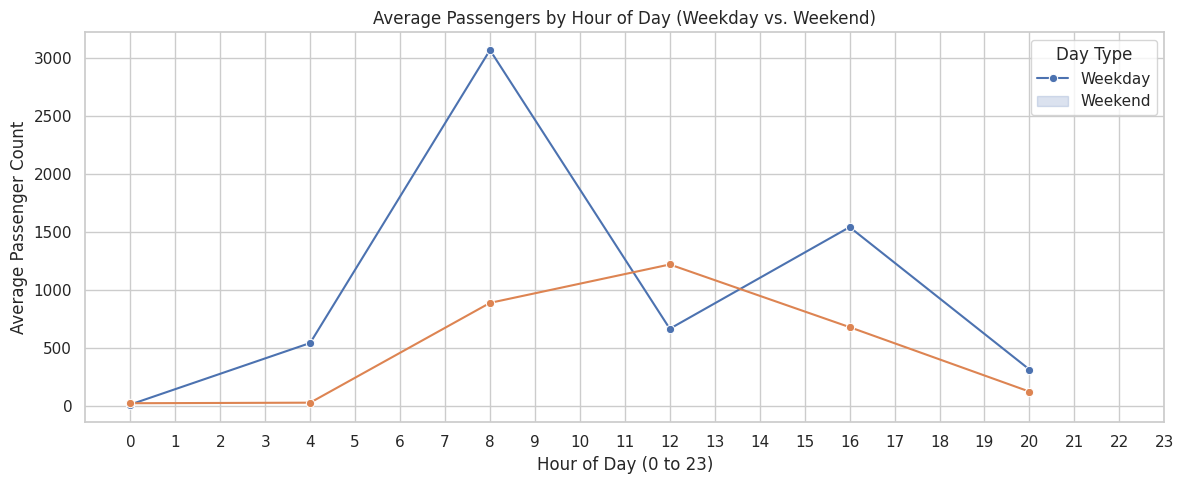

/tmp/ipykernel_3735/1824280381.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


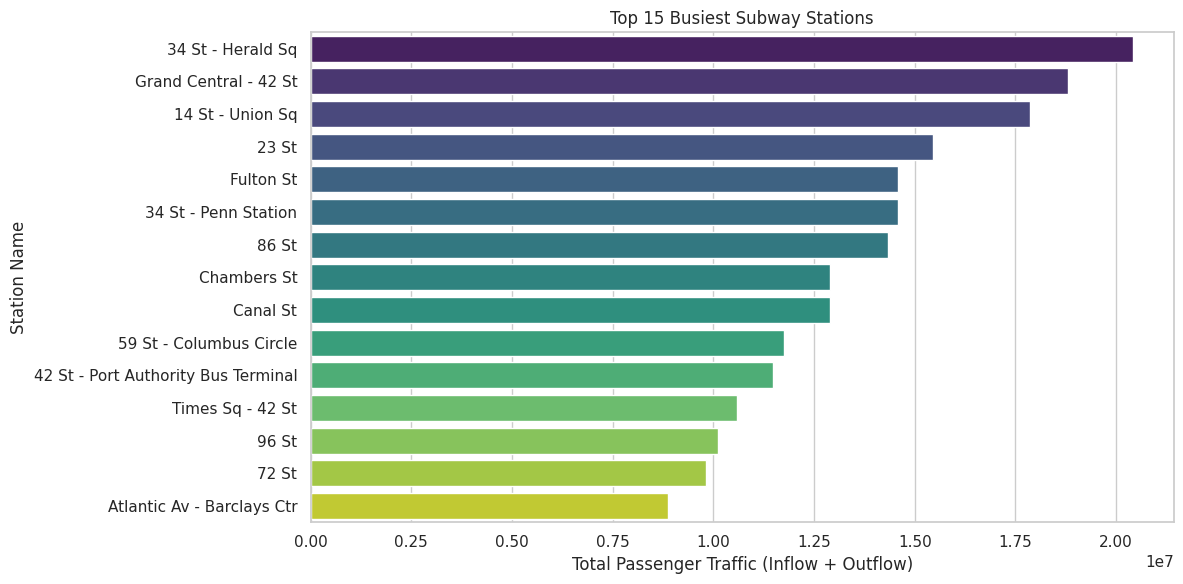

/tmp/ipykernel_3735/1824280381.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly_traffic, x="year", y="total_traffic", palette="magma")


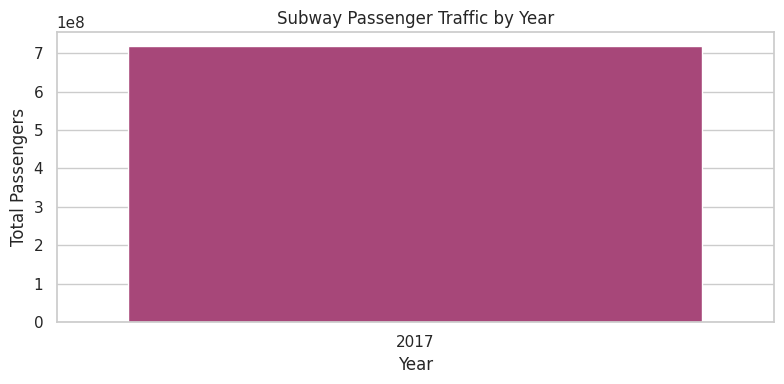

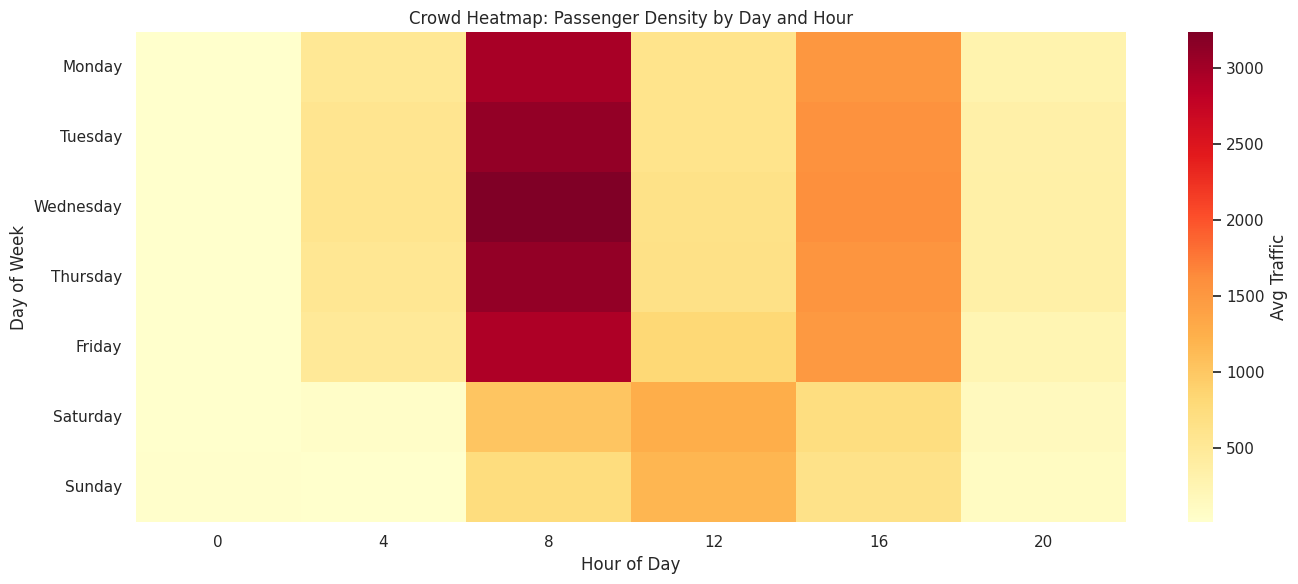

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make charts clean and easy to read
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# ==========================================
# STEP 1: LOAD THE DATASET
# ==========================================
# Read the dataset file into Python
df = pd.read_csv("nyc_subway_traffic.csv")

# Clean column headers (remove extra spaces and make letters lowercase)
df.columns = df.columns.str.strip().str.lower()

# ==========================================
# STEP 2: BASIC DATA INSPECTION
# ==========================================
print("--- DATASET OVERVIEW ---")
print(f"Total Rows and Columns: {df.shape}")

print("\n--- Column Details & Data Types ---")
df.info()

print("\n--- Missing Values Check (Before Cleaning) ---")
print(df.isnull().sum())

print("\n--- Summary Statistics ---")
print(df.describe())

# ==========================================
# STEP 3: DATE & TIME PROCESSING
# ==========================================
# Convert text dates into real date/time objects Python can understand
if "datetime" in df.columns:
    df["datetime"] = pd.to_datetime(df["datetime"])
elif "date" in df.columns and "time" in df.columns:
    df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"])
elif "date" in df.columns:
    df["datetime"] = pd.to_datetime(df["date"])

# Create new simple time columns for easy grouping
df["hour"] = df["datetime"].dt.hour
df["day_name"] = df["datetime"].dt.day_name()
df["year"] = df["datetime"].dt.year
df["is_weekend"] = df["datetime"].dt.dayofweek >= 5

# ==========================================
# STEP 4: CALCULATE PASSENGERS & FIX OUTLIERS / MISSING VALUES
# ==========================================
# Turnstiles count up continuously like a car odometer.
# We subtract previous readings from new readings to get real hourly entries and exits.
if "entries" in df.columns and "exits" in df.columns:
    # Group by individual turnstile hardware unit and station
    # The original code had 'station', which is not present. Using 'stop name' and 'remote unit' instead.
    group_cols = (
        ["stop name", "c/a", "remote unit", "scp"]
        if "scp" in df.columns
        else ["stop name", "remote unit"]
    )

    # Sort data chronologically per turnstile before subtracting
    df = df.sort_values(by=group_cols + ["datetime"])

    # 4a. Compute hourly differences
    df["net_entries"] = df.groupby(group_cols)["entries"].diff()
    df["net_exits"] = df.groupby(group_cols)["exits"].diff()

    # 4b. Remove missing values (NaNs) created by .diff() on the very first row
    df = df.dropna(subset=["net_entries", "net_exits"])

    # 4c. Fix outliers (remove negative resets and clip huge sensor spikes to max 10,000)
    df["net_entries"] = df["net_entries"].clip(lower=0, upper=10000)
    df["net_exits"] = df["net_exits"].clip(lower=0, upper=10000)

    # 4d. Total traffic = Entry count + Exit count
    df["total_traffic"] = df["net_entries"] + df["net_exits"]

print("\n--- Missing Values Check (After Cleaning) ---")
print(df.isnull().sum())

# ==========================================
# STEP 5: CHART 1 - BUSIEST HOURS OF THE DAY
# ==========================================
plt.figure(figsize=(12, 5))

# Calculate average passengers per hour for Weekdays vs. Weekends
hourly_traffic = (
    df.groupby(["hour", "is_weekend"])["total_traffic"].mean().reset_index()
)

# Plot weekday vs weekend traffic lines
sns.lineplot(
    data=hourly_traffic,
    x="hour",
    y="total_traffic",
    hue="is_weekend",
    marker="o",
)
plt.title("Average Passengers by Hour of Day (Weekday vs. Weekend)")
plt.xlabel("Hour of Day (0 to 23)")
plt.ylabel("Average Passenger Count")
plt.xticks(range(0, 24))
plt.legend(title="Day Type", labels=["Weekday", "Weekend"])
plt.tight_layout()
plt.show()

# ==========================================
# STEP 6: CHART 2 - TOP 15 BUSIEST STATIONS
# ==========================================
# Find 15 stations with the highest overall passenger count
top_stations = (
    df.groupby("stop name")["total_traffic"].sum().nlargest(15).reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_stations, x="total_traffic", y="stop name", palette="viridis"
)
plt.title("Top 15 Busiest Subway Stations")
plt.xlabel("Total Passenger Traffic (Inflow + Outflow)")
plt.ylabel("Station Name")
plt.tight_layout()
plt.show()

# ==========================================
# STEP 7: CHART 3 - YEARLY TRAFFIC TREND
# ==========================================
# Sum traffic per year
yearly_traffic = df.groupby("year")["total_traffic"].sum().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=yearly_traffic, x="year", y="total_traffic", palette="magma")
plt.title("Subway Passenger Traffic by Year")
plt.xlabel("Year")
plt.ylabel("Total Passengers")
plt.tight_layout()
plt.show()

# ==========================================
# STEP 8: CHART 4 - CONGESTION HEATMAP
# ==========================================
# Group traffic into a Day vs. Hour matrix
heatmap_data = df.pivot_table(
    index="day_name",
    columns="hour",
    values="total_traffic",
    aggfunc="mean",
).reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)

plt.figure(figsize=(14, 6))
# Draw heatmap (darker color = higher crowd congestion)
sns.heatmap(
    heatmap_data, cmap="YlOrRd", annot=False, cbar_kws={"label": "Avg Traffic"}
)
plt.title("Crowd Heatmap: Passenger Density by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()
